In [4]:
# Import libs
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import read_les_data as rd 
import glob, os




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Simulation ran for  0.025  hours
Reading in 0th snapshot of u
Reading in 0th snapshot of v
Reading in 0th snapshot of w
Reading in 0th snapshot of uw
Reading in 0th snapshot of uu
Reading in 0th snapshot of ww
Reading in 0th snapshot of txz
Move to matlab for analysis or convert script for averaged variables


TypeError: 'NoneType' object is not iterable

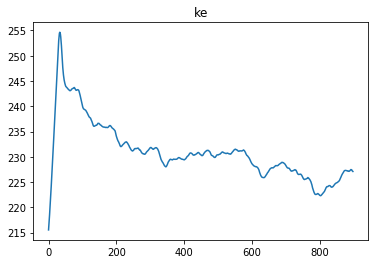

In [8]:
# Load data

sim = 'test_1_7/'
file_path = '/scratch/general/lustre/u0851921/'
output_loc = 'output/' #instantaneous-fields/'
path = file_path + sim + output_loc
vars, grid, IBM, SCALARS, SGS = rd.main(sim)

In [12]:
# Averaging and simulation variables
# sim = 'hill_test/'
# file_path = '/scratch/general/lustre/u0851921/'
# output_loc = 'output/' #instantaneous-fields/'
# path = file_path + sim + output_loc
file_path = '/scratch/general/lustre/u0851921/'
output_loc = 'output/' #instantaneous-fields/'
path = file_path + sim + output_loc
with open(file_path + sim + 'input/config.yaml', 'r') as dims:
    try:
        config = yaml.safe_load(dims)
    except yaml.YAMLError as exc:
        print(exc)

dt = config['time_step_size']
total_timesteps = config['number_of_time_steps']
timesteps_skipped = config['output.instantaneous.skip']
timesteps = total_timesteps - timesteps_skipped
frequency = config['output.instantaneous.frequency']
SCALARS = True if config['particles.active'] == 'T' else False
IBM = True if config['bc.lower.type'] == 'IBM_DFA' else False
SGS = True if config['output.instantaneous.write_stress_tensor'] == 'T' else False
plots = False

z = grid['wall_norm_z']['z-coord']; dz = grid['domain_size.z']/grid['grid_points.z']
x = grid['wall_norm_x']['x-coord']; dx = grid['domain_size.x']/grid['grid_points.x']
y = grid['wall_norm_z']['y-coord']; dy = grid['domain_size.y']/grid['grid_points.y']

uavg = rd.avg_4d(vars['u'])
vavg = rd.avg_4d(vars['v'])
wavg = rd.avg_4d(vars['w'])

if IBM: intf, iintf = rd.build_intf(grid['wall_dist']['data'], dz)
if SCALARS: pconavg = rd.avg_4d(vars['pcon'])
if SGS: shear = rd.shear_stress(vars['u'], vars['w'], vars['txz'])
if SCALARS: sc_flux = rd.shear_stress(vars['w'],vars['pcon'], vars['txz'])



# plt.figure()
# plt.plot(((rd.avg_3d(shear['Rij']))**(2))**(1/4),z)
# plt.figure()
# plt.plot(rd.avg_3d(sc_flux['Rij'])/.05,z)

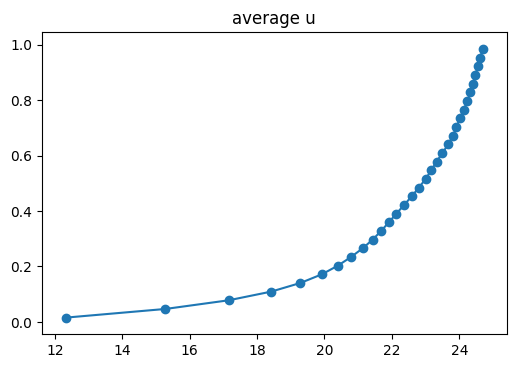

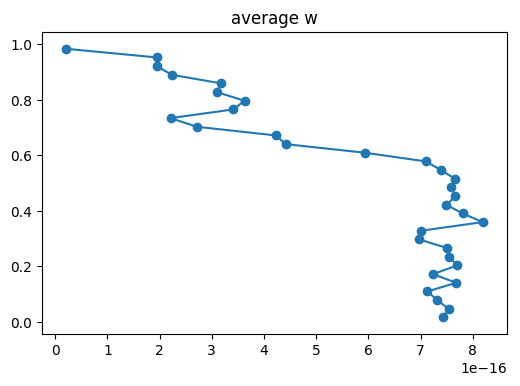

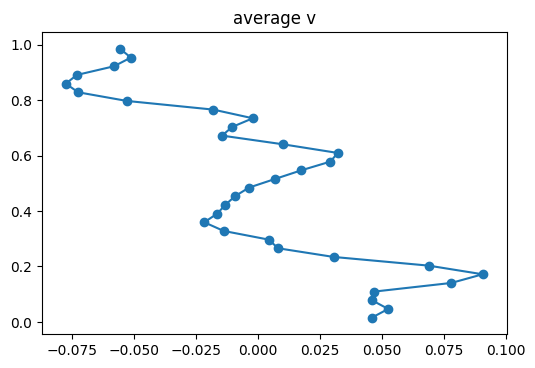

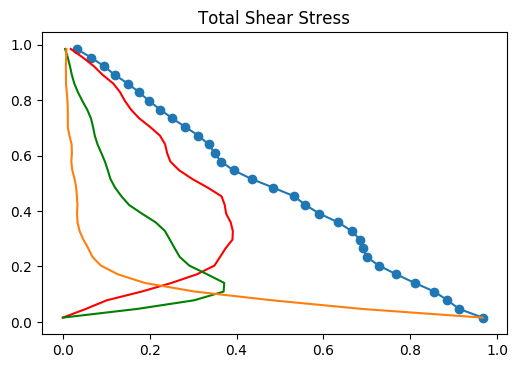

In [13]:
# Basic Plots

if not(IBM): rd.plot_1d(uavg,z,'average u')
if IBM: rd.plot_1d(uavg[int(np.max(iintf)):],z[int(np.max(iintf)):],'average uavg')
rd.plot_1d(wavg,z,'average w')
rd.plot_1d(vavg,z,'average v')
if SCALARS and IBM: rd.plot_1d(pconavg[int(np.max(iintf)):],z[int(np.max(iintf)):],'average pcon')
if SCALARS and not(IBM): rd.plot_1d(pconavg, z, 'average pcon')
if SGS:
    rd.plot_1d(-shear['total'], z, 'Total Shear Stress')
    plt.plot(-rd.avg_3d(shear['Rij']),z, 'r-')
    plt.plot(-shear['disp'],z,'g-')
    plt.plot(rd.avg_4d(shear['tau']),z)
    if IBM: plt.hlines(np.max(intf), 0, np.max(-shear['total']),'k')



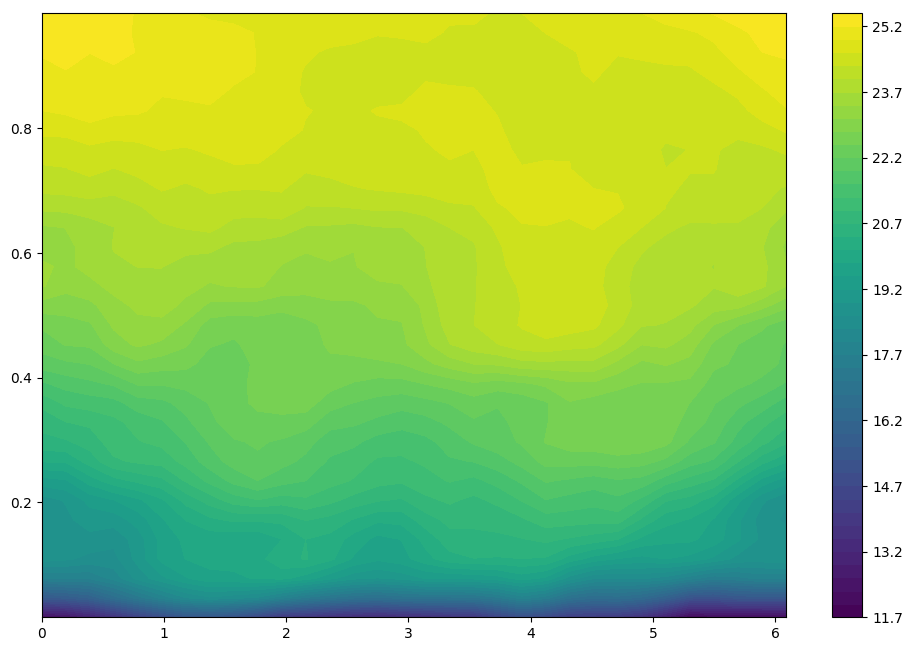

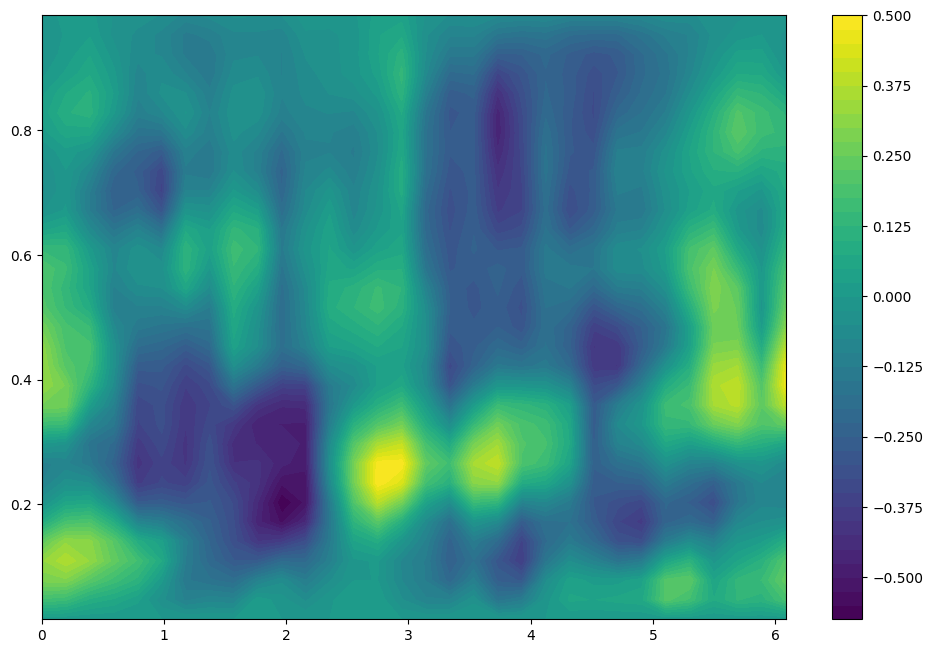

In [14]:
# Contour Plots
X,Z = np.meshgrid(x,z)
X1,Y = np.meshgrid(x,y)
jcut = 16

if SCALARS:
    fig = plt.figure(figsize=(12,8), dpi= 100)
    CS = plt.contourf(X,Z,np.squeeze(rd.avg_time(vars['pcon'],1,int(timesteps/frequency))[:,jcut,:]).T,50)
    cbar = fig.colorbar(CS)
    
#     fig = plt.figure(figsize=(12,8), dpi= 100)
#     CS = plt.contourf(X,Z,np.squeeze(rd.avg_time(vars['dep'],0,int(timesteps/frequency))[:,16,:]).T,50)
#     cbar = fig.colorbar(CS)

fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X,Z,np.squeeze(rd.avg_time(vars['u'],1,int(timesteps/frequency))[:,jcut,:]).T,50)
cbar = fig.colorbar(CS)

fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X,Z,np.squeeze(rd.avg_time(vars['w'],1,int(timesteps/frequency))[:,jcut,:]).T,50)
cbar = fig.colorbar(CS)


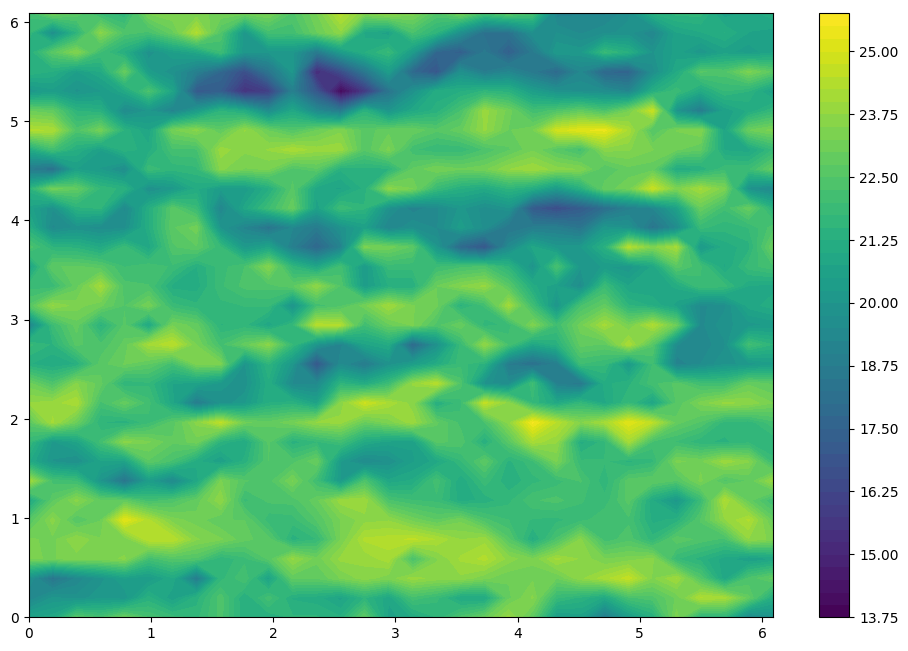

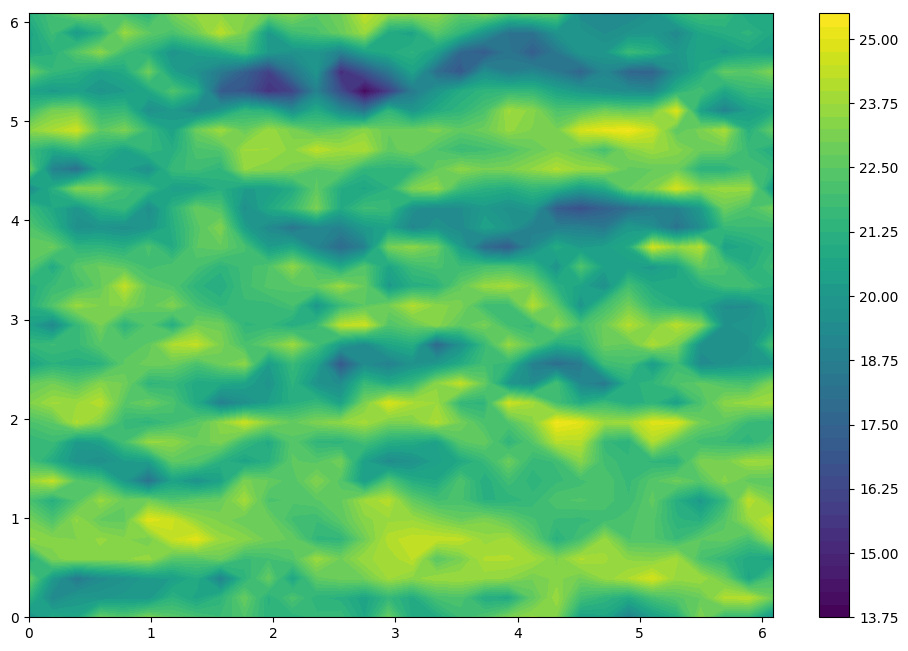

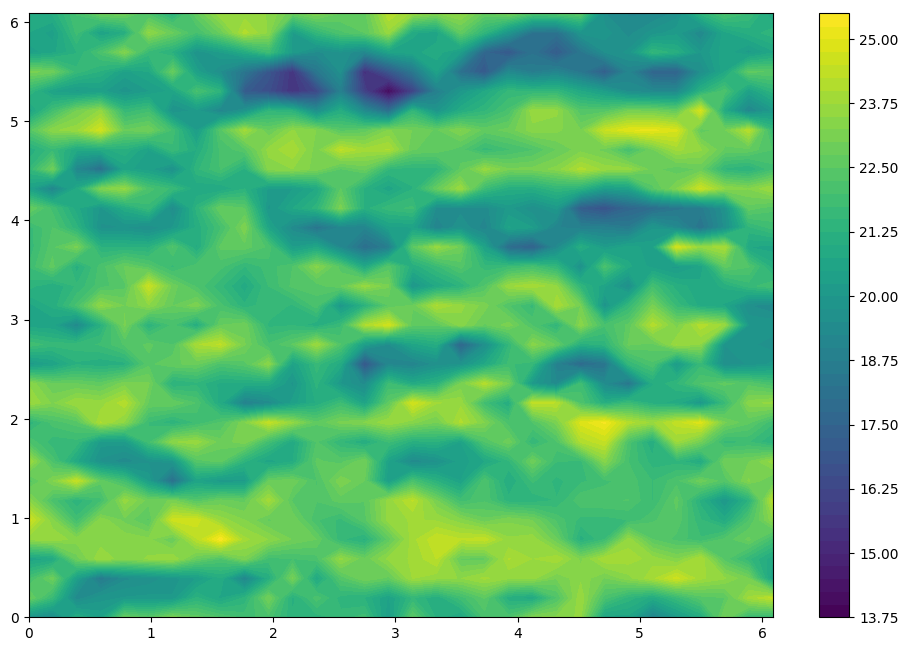

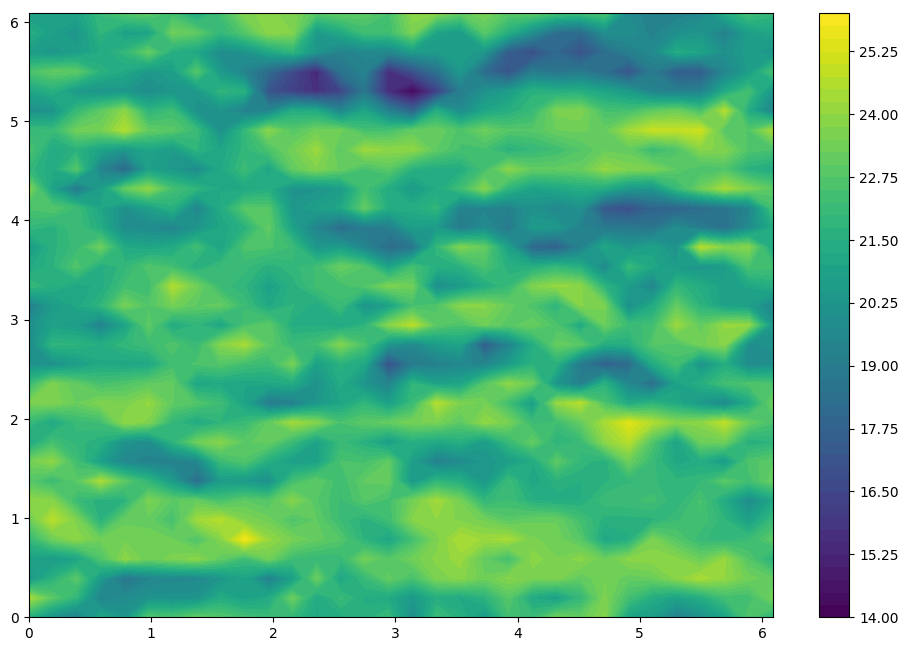

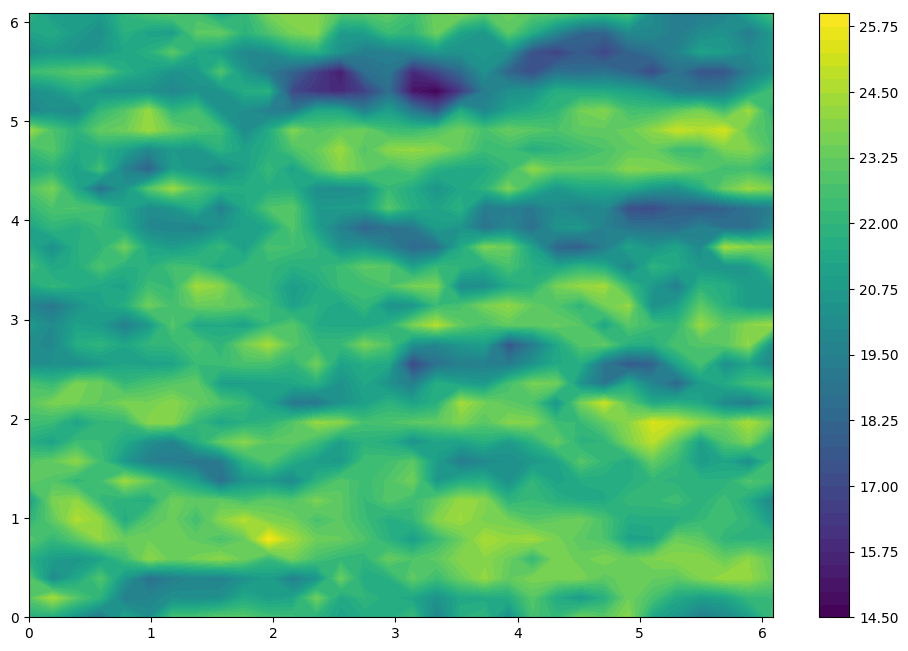

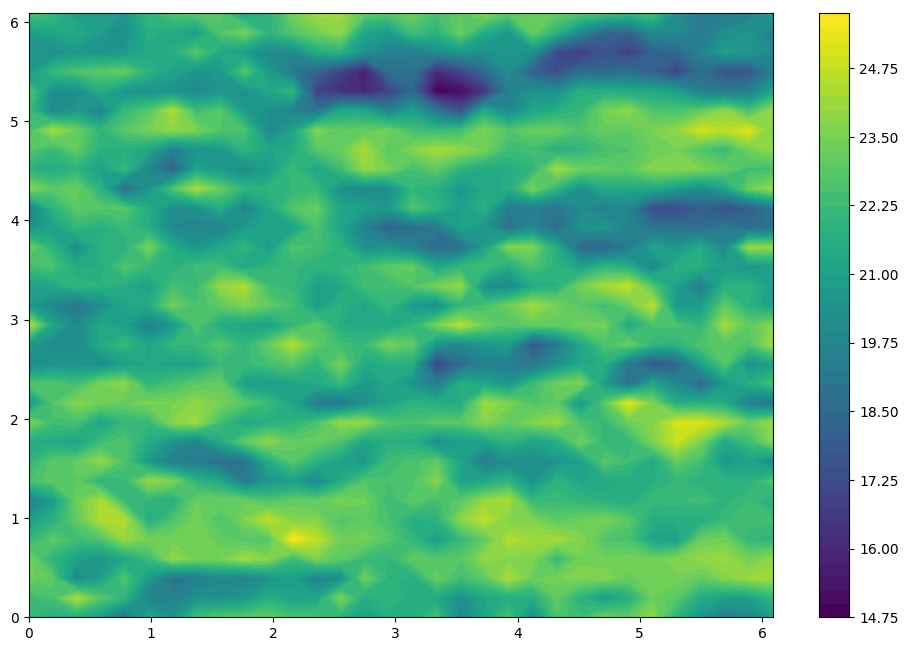

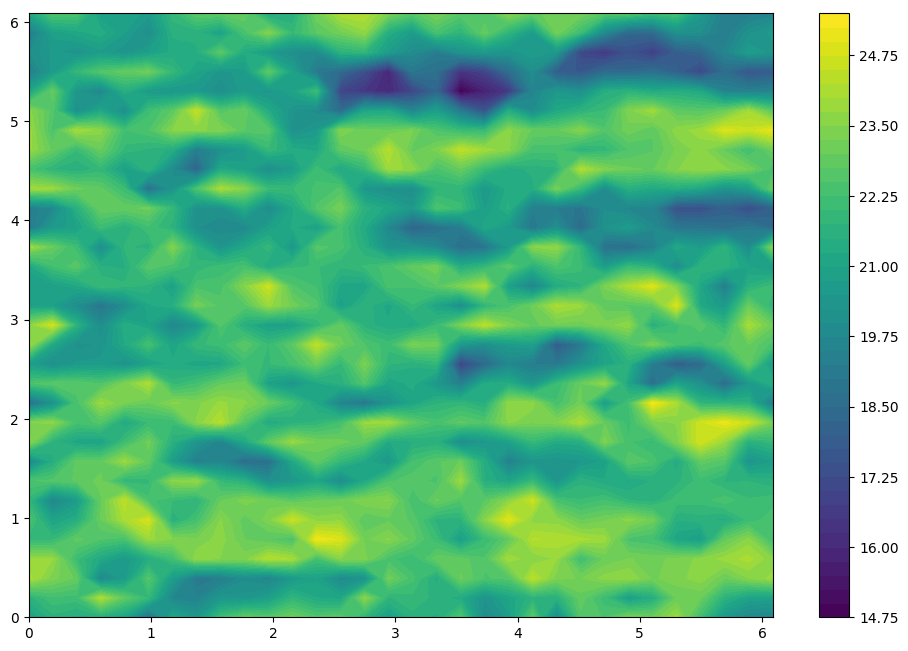

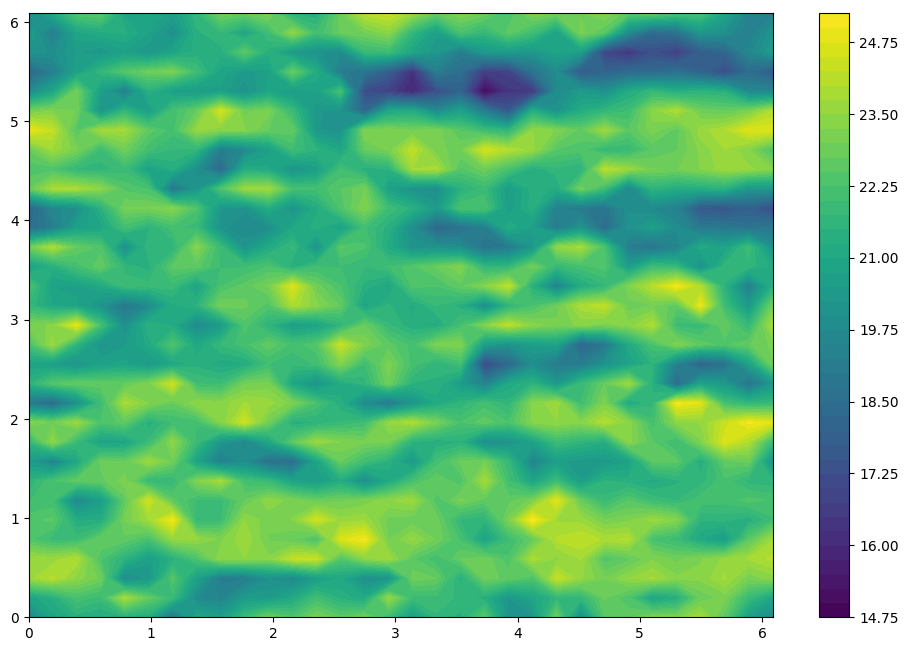

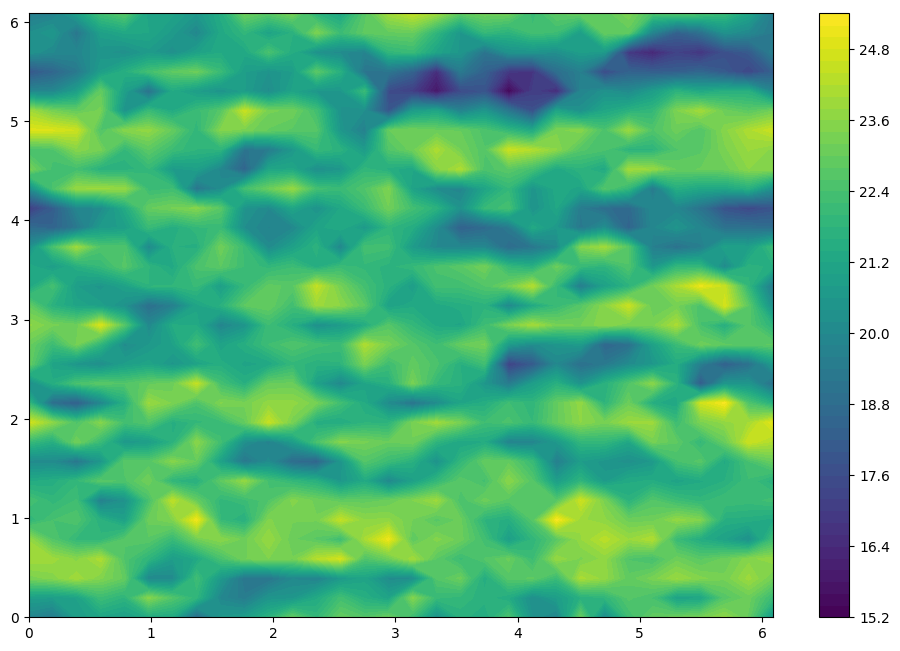

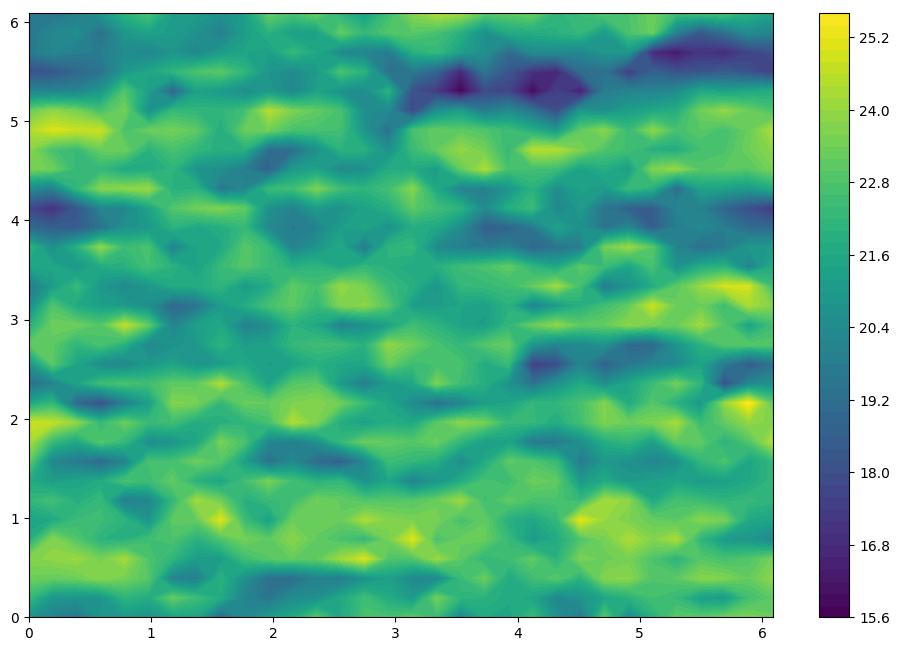

In [15]:
kcut = 10
strr = 'u'
fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X1,Y,np.squeeze(vars[strr][:,:,kcut,0]).T,50)
cbar = fig.colorbar(CS)
fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X1,Y,np.squeeze(vars[strr][:,:,kcut,1]).T,50)
cbar = fig.colorbar(CS)
fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X1,Y,np.squeeze(vars[strr][:,:,kcut,2]).T,50)
cbar = fig.colorbar(CS)
fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X1,Y,np.squeeze(vars[strr][:,:,kcut,3]).T,50)
cbar = fig.colorbar(CS)
fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X1,Y,np.squeeze(vars[strr][:,:,kcut,4]).T,50)
cbar = fig.colorbar(CS)
fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X1,Y,np.squeeze(vars[strr][:,:,kcut,5]).T,50)
cbar = fig.colorbar(CS)
fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X1,Y,np.squeeze(vars[strr][:,:,kcut,6]).T,50)
cbar = fig.colorbar(CS)
fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X1,Y,np.squeeze(vars[strr][:,:,kcut,7]).T,50)
cbar = fig.colorbar(CS)
fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X1,Y,np.squeeze(vars[strr][:,:,kcut,8]).T,50)
cbar = fig.colorbar(CS)
fig = plt.figure(figsize=(12,8), dpi= 100)
CS = plt.contourf(X1,Y,np.squeeze(vars[strr][:,:,kcut,9]).T,50)
cbar = fig.colorbar(CS)


1980.7499999999998


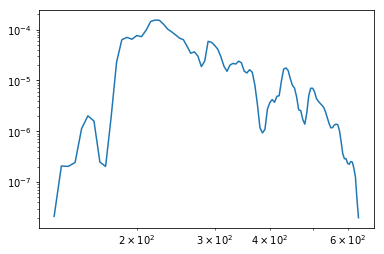

In [15]:
# Reproduce Chamecki 2009 Results
#Mean Centerline concentration 

pconavg_t = rd.avg_time(vars['pcon'],20, 25)
cc = pconavg_t[26:,32,8]
total_released = .11875*dt*total_timesteps
print(total_released)
plt.figure
plt.loglog(x[26:],cc)

In [34]:
np.shape(vars['pcon'])

(128, 64, 96, 25)